# NYC TLC Trip Data 분석

## 1. 환경설정

In [1]:
import sys
sys.path.append('/opt/spark-apps')

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("spark://spark-master:7077")
    .appName("NYCTaxiAnalysis")
    .getOrCreate()
)

print("Spark version:", spark.version)
print("Master:", spark.sparkContext.master)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/23 07:34:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.9
Master: spark://spark-master:7077


## 2. 데이터 적재

In [2]:
from pathlib import Path
from download_data import download_tlc_months, fetch_weather
from pipeline import load_trips, load_weather

YEAR_MONTHS = [(2024, 1)]
START_DATE, END_DATE = "2024-01-01", "2024-01-31"

RAW_TLC_DIR = Path("/opt/spark-data/raw/tlc")
RAW_WEATHER_PATH = Path("/opt/spark-data/raw/weather/nyc_weather.csv")

tlc_paths = download_tlc_months(YEAR_MONTHS, RAW_TLC_DIR)
weather_path = fetch_weather(START_DATE, END_DATE, RAW_WEATHER_PATH)

trips_df = load_trips(spark, str(RAW_TLC_DIR / "*.parquet"))
weather_df = load_weather(spark, str(weather_path))

print("Trips loaded:", trips_df.count())
print("Weather rows loaded:", weather_df.count())


Trips loaded: 2964624
Weather rows loaded: 744


## 3. 클리닝

In [3]:
from pipeline import clean_trips

raw_count = trips_df.count()
cleaned_df = clean_trips(trips_df).cache()
cleaned_count = cleaned_df.count()

print(f"Raw rows: {raw_count}")
print(f"Cleaned rows: {cleaned_count} ({cleaned_count / raw_count:.1%} kept)")


Raw rows: 2964624
Cleaned rows: 2868080 (96.7% kept)


## 4. 지표 계산

In [4]:
from pipeline import compute_summary_metrics

summary_df = compute_summary_metrics(cleaned_df)
summary_df.toPandas()


,avg_trip_duration_min,avg_trip_distance_mi,trip_count
0,14.95558,3.292097,2868080


## 5. 피크아워 분석

Peak hours:
    pickup_hour  trip_count
18           18      206159
17           17      200171
16           16      184828


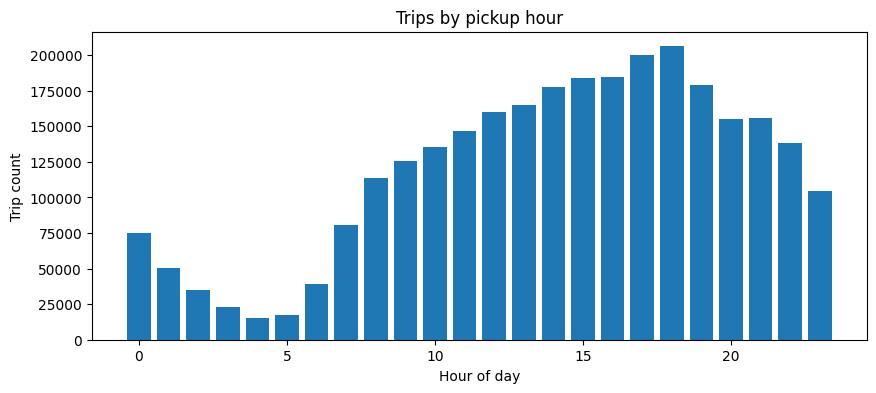

In [5]:
import matplotlib.pyplot as plt
from pipeline import compute_hourly_trip_counts

hourly_counts_df = compute_hourly_trip_counts(cleaned_df)
hourly_counts_pdf = hourly_counts_df.toPandas()

top_hours = hourly_counts_pdf.nlargest(3, "trip_count")
print("Peak hours:")
print(top_hours)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly_counts_pdf["pickup_hour"], hourly_counts_pdf["trip_count"])
ax.set_xlabel("Hour of day")
ax.set_ylabel("Trip count")
ax.set_title("Trips by pickup hour")
plt.show()


## 6. 날씨 상관분석

Correlations: {'temperature_r': 0.27602553683226205, 'temperature_p': 1.778202220570848e-14, 'precipitation_r': -0.09756007855266437, 'precipitation_p': 0.007745554226064105}
Rain vs dry stats: {'rainy_mean_trip_count': 3807.8212290502793, 'dry_mean_trip_count': 3869.8460176991152, 't_stat': -0.32683604844201186, 'p_value': 0.744015683319543}


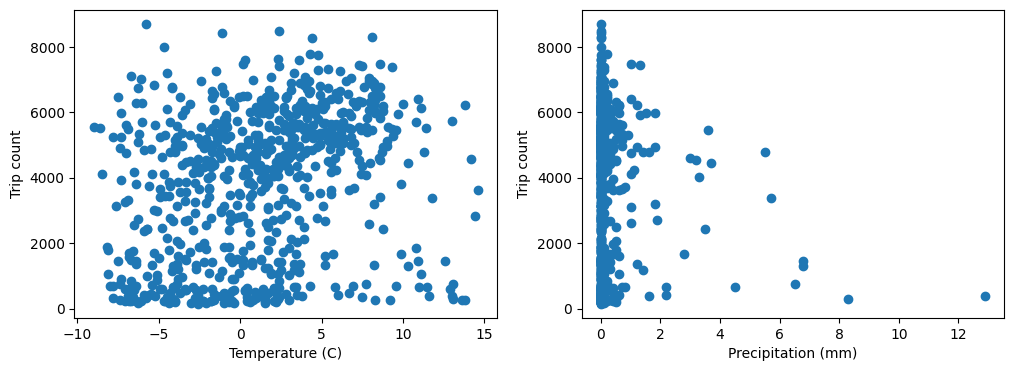

In [6]:
from pipeline import (
    compute_hourly_trip_series,
    join_hourly_weather,
    compute_correlations,
    compute_weather_condition_stats,
)

hourly_series_df = compute_hourly_trip_series(cleaned_df)
weather_join_df = join_hourly_weather(hourly_series_df, weather_df)
weather_join_pdf = weather_join_df.toPandas()

correlations = compute_correlations(weather_join_pdf)
condition_stats = compute_weather_condition_stats(weather_join_pdf)

print("Correlations:", correlations)
print("Rain vs dry stats:", condition_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(weather_join_pdf["temperature_2m"], weather_join_pdf["trip_count"])
axes[0].set_xlabel("Temperature (C)")
axes[0].set_ylabel("Trip count")
axes[1].scatter(weather_join_pdf["precipitation"], weather_join_pdf["trip_count"])
axes[1].set_xlabel("Precipitation (mm)")
axes[1].set_ylabel("Trip count")
plt.show()


## 7. 시각화/출력

Saved outputs to /opt/spark-data/output


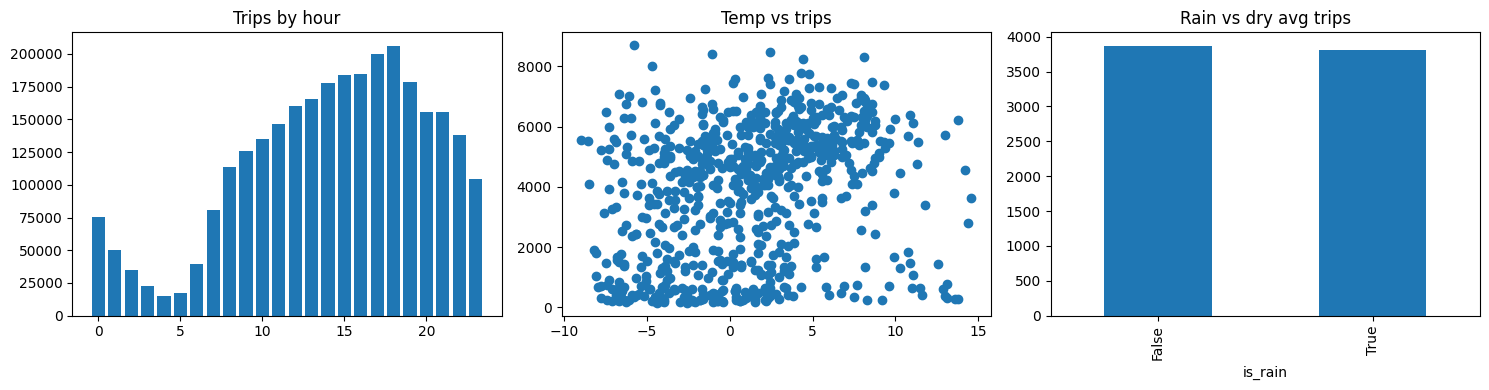

In [7]:
from pipeline import write_output_table, stats_to_dataframe

OUTPUT_DIR = "/opt/spark-data/output"

write_output_table(summary_df, OUTPUT_DIR, "summary_metrics")
write_output_table(hourly_counts_df, OUTPUT_DIR, "hourly_trip_counts")
write_output_table(weather_join_df, OUTPUT_DIR, "hourly_weather_join")
write_output_table(
    stats_to_dataframe(spark, {**correlations, **condition_stats}),
    OUTPUT_DIR,
    "weather_condition_stats",
)

print("Saved outputs to", OUTPUT_DIR)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(hourly_counts_pdf["pickup_hour"], hourly_counts_pdf["trip_count"])
axes[0].set_title("Trips by hour")
axes[1].scatter(weather_join_pdf["temperature_2m"], weather_join_pdf["trip_count"])
axes[1].set_title("Temp vs trips")
rain_group = weather_join_pdf.assign(is_rain=weather_join_pdf["precipitation"] > 0)
rain_group.groupby("is_rain")["trip_count"].mean().plot(kind="bar", ax=axes[2])
axes[2].set_title("Rain vs dry avg trips")
plt.tight_layout()
plt.show()
